# 📊 MACD (Moving Average Convergence Divergence) Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **MACD (Moving Average Convergence Divergence)** indicator.  
MACD is both a **trend-following** and **momentum** indicator, showing the relationship between two moving averages.

It consists of three elements:
- **MACD line** = EMA(12) – EMA(26)  
- **Signal line** = EMA(9) of the MACD line  
- **Histogram** = MACD line – Signal line  

---

## 🔹 Technical Background

### Formulas
1. Fast & Slow Exponential Moving Averages:
\[
EMA_{fast} = EMA_{12}(Close), \quad EMA_{slow} = EMA_{26}(Close)
\]

2. MACD line:
\[
MACD_t = EMA_{fast}(t) - EMA_{slow}(t)
\]

3. Signal line:
\[
Signal_t = EMA_{9}(MACD_t)
\]

4. Histogram:
\[
Hist_t = MACD_t - Signal_t
\]



In [1]:
print("Hello World!")

Hello World!


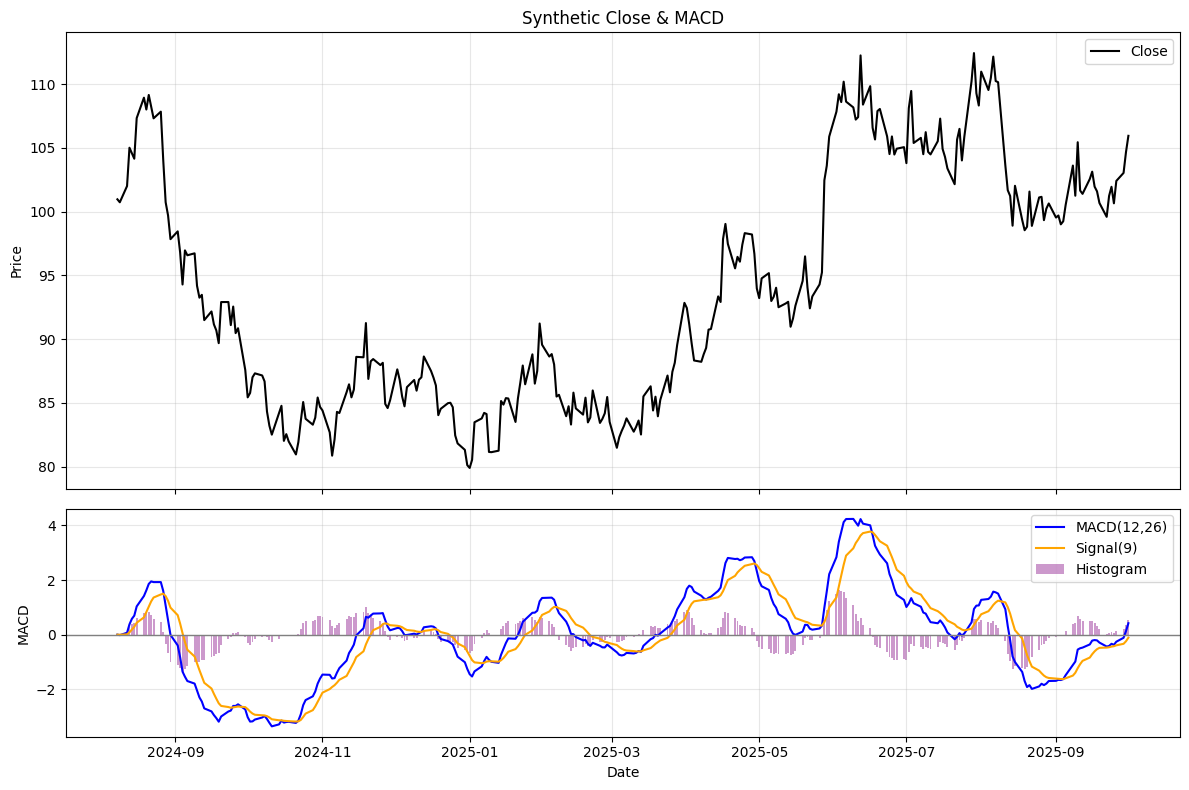

Mode: Synthetic
Rows: 300
Last Close: 105.95
MACD: 0.4177 | Signal: -0.112 | Hist: 0.5297


In [2]:
# ==== MACD Indicator Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # used only if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"

FAST  = 12   # fast EMA
SLOW  = 26   # slow EMA
SIGNAL= 9    # signal line EMA
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        close = pd.to_numeric(df["Close"], errors="coerce").dropna()
        title = f"{TICKER} Close & MACD"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=300)
    mu, sigma, dt = 0.12, 0.30, 1/252
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    title = "Synthetic Close & MACD"

# 2) Compute MACD
ema_fast = close.ewm(span=FAST, adjust=False).mean()
ema_slow = close.ewm(span=SLOW, adjust=False).mean()
macd_line = ema_fast - ema_slow
signal_line = macd_line.ewm(span=SIGNAL, adjust=False).mean()
hist = macd_line - signal_line

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Price chart
ax1.plot(close.index, close, label="Close", color="black")
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# MACD chart
ax2.plot(macd_line.index, macd_line, label=f"MACD({FAST},{SLOW})", color="blue")
ax2.plot(signal_line.index, signal_line, label=f"Signal({SIGNAL})", color="orange")
ax2.bar(hist.index, hist, label="Histogram", color="purple", alpha=0.4)
ax2.axhline(0, color="gray", linewidth=1)
ax2.set_ylabel("MACD")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"MACD: {round(macd_line.iloc[-1],4)} | Signal: {round(signal_line.iloc[-1],4)} | Hist: {round(hist.iloc[-1],4)}")
